In [1]:
# First, load the IPython extension for auto-reloading
%load_ext autoreload
%autoreload 2

import pickle
import torch
from torch.utils.data import ConcatDataset, DataLoader
import sys
import os
import numpy as np
from pathlib import Path
from typing import Dict, List, Tuple
sys.path.append(str(Path.cwd().parent))

from src.eval.evaluate_model import (
    evaluate_model,
    evaluate_by_hydrophone,
    evaluate_by_anomaly_type,
    plot_confusion_matrix,
    plot_example_spectrograms,
    plot_threshold_f1f2_curve,
    plot_all_false_positives,
    plot_all_false_negatives,
    plot_anomaly_type_metrics,
    plot_anomaly_type_by_hydrophone,
    plot_co_occurrence_matrix,
    analyze_excluded_data,
    analyze_full_test_set
    
)
from src.utilities.training_utils import create_model
from src.onc_dataset import ONCSpectrogramDataset, get_onc_spectrogram_data
from src.models import AMBAModel

/home/merileo/ssamba/myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/merileo/ssamba/myenv/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/merileo/ssamba/myenv/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


VisionMamba imported successfully
RMSNorm imported successfully


In [2]:
#EXCLUDED_LABELS = ["Dropout",]
EXCLUDED_LABELS = ["Dropout", "Tonal"]
#EXCLUDED_LABELS = []

In [3]:
# Path to your model directory
#model_dir = Path("/scratch/merileo/exp/finetune/amba-base-f16-t16-b16-lr1e-4-m300-custom-tr0.8-full_dataset_hydrophones-excludeDropout-exclDropout")
model_dir = Path("/scratch/merileo/exp/finetune/amba-base-f16-t16-b16-lr1e-4-m300-custom-tr0.8-full_dataset_hydrophones-exclDropout_Tonal")
checkpoint_path = str(model_dir / "models/ft-cls_best_checkpoint.pth")

# Load the saved args
with open(model_dir / "args.pkl", "rb") as f:
    args = pickle.load(f)

# Create and load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = create_model(args)
model = model.to(device)

# Load checkpoint
checkpoint = torch.load(checkpoint_path, map_location=device)
if 'model_state_dict' in checkpoint:
    state_dict = checkpoint['model_state_dict']
else:
    state_dict = checkpoint

model.load_state_dict(state_dict)

Vision Mamba Config: {'img_size': (512, 512), 'patch_size': 16, 'stride': 16, 'embed_dim': 768, 'depth': 24, 'channels': 1, 'num_classes': 2, 'drop_rate': 0.0, 'drop_path_rate': 0.1, 'norm_epsilon': 1e-05, 'rms_norm': False, 'residual_in_fp32': False, 'fused_add_norm': False, 'if_rope': False, 'if_rope_residual': False, 'bimamba_type': 'v2', 'if_cls_token': True, 'if_divide_out': True, 'use_double_cls_token': False, 'use_middle_cls_token': False, 'if_bidirectional': True, 'final_pool_type': 'none', 'if_abs_pos_embed': True, 'if_bimamba': False}
Loading pretrained model from: /scratch/merileo/exp/pretrain/amba-base-f16-t16-b16-lr1e-4-m300-custom-tr0.8-full_dataset_hydrophones_FINAL/models/pretrain-joint_best_checkpoint.pth
Loaded state dict keys: dict_keys(['epoch', 'global_step', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'best_metrics', 'val_acc', 'args'])
Now loading SSL pretrained model from /scratch/merileo/exp/pretrain/amba-base-f16-t16-b16-lr1e-4-m300-cus

<All keys matched successfully>

In [4]:
# Load the test data
data_path = '/scratch/merileo/different_locations_incl_backgroundpipelinenormals_multilabel.h5'

_, _, test_dataset, _, _, excluded_test_dataset = get_onc_spectrogram_data(
    data_path=data_path,
    seed=args.split_seed,
    train_ratio=args.train_ratio,
    val_ratio=args.val_ratio,
    target_length=args.target_length,
    num_mel_bins=args.num_mel_bins,
    freqm=args.freqm,
    timem=args.timem,
    dataset_mean=args.dataset_mean,
    dataset_std=args.dataset_std,
    mixup=args.mixup,
    ood=-1,  # No OOD filtering
    amount=1.0,
    subsample_test=False,
    exclude_labels=EXCLUDED_LABELS
)

# Create separate dataloaders for each dataset
test_loader = DataLoader(
    test_dataset,
    batch_size=args.batch_size,
    shuffle=False,
    num_workers=2
)

excluded_test_loader = DataLoader(
    excluded_test_dataset,
    batch_size=args.batch_size,
    shuffle=False,
    num_workers=2
)

# Create a combined dataset for the full test set
full_test_dataset = ConcatDataset([test_dataset, excluded_test_dataset])
full_test_loader = DataLoader(
    full_test_dataset,
    batch_size=args.batch_size,
    shuffle=False,
    num_workers=2
)


=== DATASET CONFIGURATION ===
Data path: /scratch/merileo/different_locations_incl_backgroundpipelinenormals_multilabel.h5
Split ratios - Train: 80.0%, Val: 10.0%, Test: 9.999999999999995%
Random seed: 42
Excluding labels: ['Dropout', 'Tonal']

=== EXCLUSION ANALYSIS ===
Labels being excluded: ['Dropout', 'Tonal']

Combinations containing excluded labels:
--------------------------------------------------
  - Tonal: 794 samples
  - Dropout + Tonal: 669 samples
  - Dropout: 296 samples
  - Dropout + Tonal + Unknown Feature: 88 samples
  - Engine Noise + Tonal: 47 samples
  - Dropout + Rain + Tonal: 40 samples
  - Dropout + Tonal + Unknown Feature + Unknown Feature: 38 samples
  - Dropout + Rain + Tonal + Unknown Feature + Unknown Feature: 23 samples
  - Dropout + Engine Noise + Tonal: 19 samples
  - Dropout + Rain + Tonal + Unknown Feature: 6 samples
  - Anomaly + Data Gap + Dropout + Tonal: 6 samples
  - Dropout + Engine Noise + Tonal + Unknown Feature: 2 samples
  - Dropout + Unknown

In [5]:
def analyze_model_performance(
    model: torch.nn.Module,
    test_loader: DataLoader,
    excluded_test_loader: DataLoader,
    full_test_loader: DataLoader,
    excluded_labels: List[str],
    device: str = 'cuda',
    threshold: float = 0.5,
    task: str = 'ft_cls'
) -> Dict:
    """Analyze model performance on regular, excluded, and full test sets"""
    
    print("\n=== Dataset Sizes ===")
    print(f"Regular test set size: {len(test_loader.dataset)}")
    print(f"Excluded test set size: {len(excluded_test_loader.dataset)}")
    print(f"Full test set size: {len(full_test_loader.dataset)}")
    
    print("\nStarting model performance analysis...")
    print(f"Excluded labels: {excluded_labels}")

    # 1. Evaluate on regular test set
    print("\n=== Evaluating on regular test set (no excluded labels) ===")
    reg_metrics, reg_y_true, reg_y_pred, reg_sources = evaluate_model(
        model, test_loader, device, threshold, task
    )
    print(f"Regular test set predictions shape: {reg_y_pred.shape}")
    
    # 2. Evaluate on excluded test set
    print("\n=== Evaluating on excluded test set ===")
    excl_metrics, excl_y_true, excl_y_pred, excl_sources = evaluate_model(
        model, excluded_test_loader, device, threshold, task
    )
    print(f"Excluded test set predictions shape: {excl_y_pred.shape}")
    
    # 3. Evaluate on full test set - Modified to ensure we get all predictions
    print("\n=== Evaluating on full test set ===")
    full_metrics, full_y_true, full_y_pred, full_sources = evaluate_model(
        model, full_test_loader, device, threshold, task
    )
    print(f"Full test set predictions shape: {full_y_pred.shape}")
    
    # Verify sizes match
    expected_full_size = len(reg_y_pred) + len(excl_y_pred)
    actual_full_size = len(full_y_pred)
    print(f"\nSize verification:")
    print(f"Regular + Excluded: {expected_full_size}")
    print(f"Full test set: {actual_full_size}")
    
    if expected_full_size != actual_full_size:
        print("WARNING: Size mismatch in predictions!")
    
    # Print metrics comparison
    print("\n=== Metrics Comparison ===")
    metrics_table = {
        "Regular Test Set": reg_metrics,
        "Excluded Test Set": excl_metrics,
        "Full Test Set": full_metrics
    }
    
    for dataset_name, metrics in metrics_table.items():
        print(f"\n{dataset_name}:")
        for metric_name, value in metrics.items():
            print(f"{metric_name}: {value:.4f}")
    
    # Continue with detailed analysis using the correct full_y_pred
    print("\n=== Detailed Analysis of Excluded Labels ===")
    excluded_analysis = analyze_excluded_data(
        excluded_test_loader.dataset,  # Use only excluded dataset
        excl_y_pred,  # Use predictions from excluded set
        excluded_labels
    )
    
    print("\n=== Full Test Set Analysis with Breakdown ===")
    full_analysis = analyze_full_test_set(
        full_test_loader.dataset,
        full_y_pred,
        excluded_labels
    )
    
    return {
        'regular_metrics': reg_metrics,
        'excluded_metrics': excl_metrics,
        'full_metrics': full_metrics,
        'excluded_analysis': excluded_analysis,
        'full_analysis': full_analysis,
        'predictions': {
            'regular': reg_y_pred,
            'excluded': excl_y_pred,
            'full': full_y_pred
        }
    }

In [6]:
# Run the analysis
results = analyze_model_performance(
    model=model,
    test_loader=test_loader,
    excluded_test_loader=excluded_test_loader,
    full_test_loader=full_test_loader,
    excluded_labels=EXCLUDED_LABELS,
    device=device,
    threshold=0.1
)


=== Dataset Sizes ===
Regular test set size: 1650
Excluded test set size: 2033
Full test set size: 3683

Starting model performance analysis...
Excluded labels: ['Dropout', 'Tonal']

=== Evaluating on regular test set (no excluded labels) ===
Regular test set predictions shape: (1650,)

=== Evaluating on excluded test set ===
Excluded test set predictions shape: (2033,)

=== Evaluating on full test set ===
Full test set predictions shape: (3683,)

Size verification:
Regular + Excluded: 3683
Full test set: 3683

=== Metrics Comparison ===

Regular Test Set:
accuracy: 0.8842
precision: 0.9464
recall: 0.7737
f1: 0.8514
f2: 0.8030
normal_acc: 0.9671
anomaly_acc: 0.7737

Excluded Test Set:
accuracy: 0.2597
precision: 1.0000
recall: 0.2597
f1: 0.4123
f2: 0.3048
normal_acc: 0.0000
anomaly_acc: 0.2597

Full Test Set:
accuracy: 0.5395
precision: 0.9720
recall: 0.3923
f1: 0.5590
f2: 0.4455
normal_acc: 0.9671
anomaly_acc: 0.3923

=== Detailed Analysis of Excluded Labels ===

EXCLUDED LABELS ANAL

In [7]:
# Get normal samples from test_dataset
normal_samples = [sample for sample in test_dataset.sample_info if not sample['is_anomalous']]

# Add normal samples to the excluded test dataset
excluded_test_dataset.sample_info = normal_samples + excluded_test_dataset.sample_info
excluded_test_dataset.indices = np.array([s['index'] for s in excluded_test_dataset.sample_info])

# Recreate the data loader with the updated dataset
excluded_test_loader = torch.utils.data.DataLoader(
    excluded_test_dataset,
    batch_size=excluded_test_loader.batch_size,
    shuffle=False,
    num_workers=excluded_test_loader.num_workers,
    pin_memory=True
)

## Understanding F-beta, F1, and F2 Metrics

The **F-beta score** combines precision and recall, with $\beta$ weighting recall relative to precision:

$F_\beta = (1 + \beta^2) \times \frac{\text{Precision} \times \text{Recall}}{(\beta^2 \times \text{Precision}) + \text{Recall}}$

**F1 Score ($\beta = 1$):**

*   Harmonic mean of precision and recall, giving equal weight to both.
*   $F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$
*   Useful for balanced precision and recall.

**F2 Score ($\beta = 2$):**

*   Weights recall more heavily than precision.
*   $F_2 = 5 \times \frac{\text{Precision} \times \text{Recall}}{(4 \times \text{Precision}) + \text{Recall}}$
*   Useful when minimizing false negatives (prioritizing recall) is important.

**Impact of Varying Classification Thresholds:**

As the classification threshold changes, precision and recall fluctuate, influencing F1 and F2 scores.

*   **F1 Score:** Reflects a balance, typically peaking where precision and recall are reasonably high.
*   **F2 Score:** More sensitive to recall changes. It may continue to rise with lower thresholds (higher recall, potentially lower precision) even as F1 declines, due to recall's greater weight.

Plotting these metrics against the threshold reveals the trade-offs and helps select a threshold aligning with specific error cost priorities.

/home/merileo/ssamba/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


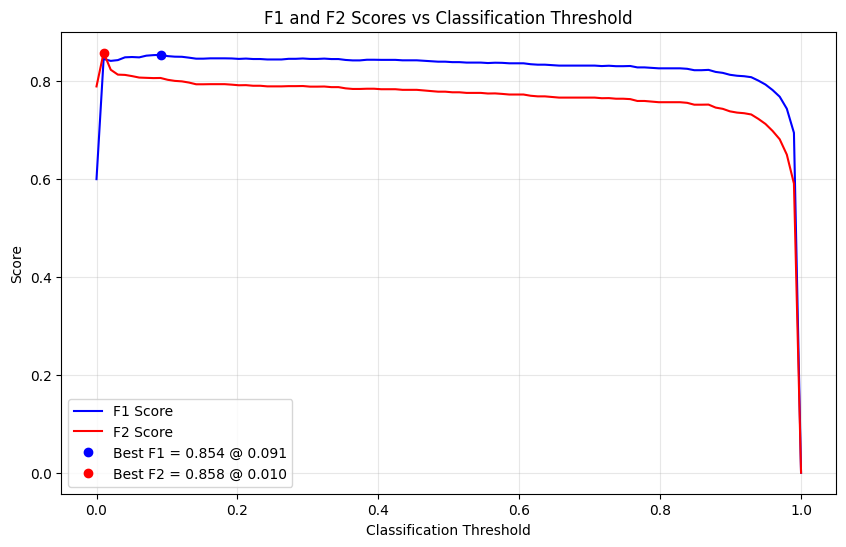

F1: Best score 0.854 at threshold 0.091
F2: Best score 0.858 at threshold 0.010


In [8]:
opt_thresh_f1, opt_thresh_f2, best_f1, best_f2 = plot_threshold_f1f2_curve(
    model=model,
    test_loader=test_loader,
    device=device,
    task=args.task
)

print(f"F1: Best score {best_f1:.3f} at threshold {opt_thresh_f1:.3f}")
print(f"F2: Best score {best_f2:.3f} at threshold {opt_thresh_f2:.3f}")

In [6]:
THRESHOLD = 0.01


=== Evaluating Original Test Set (Non-excluded Data) ===


/home/merileo/ssamba/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


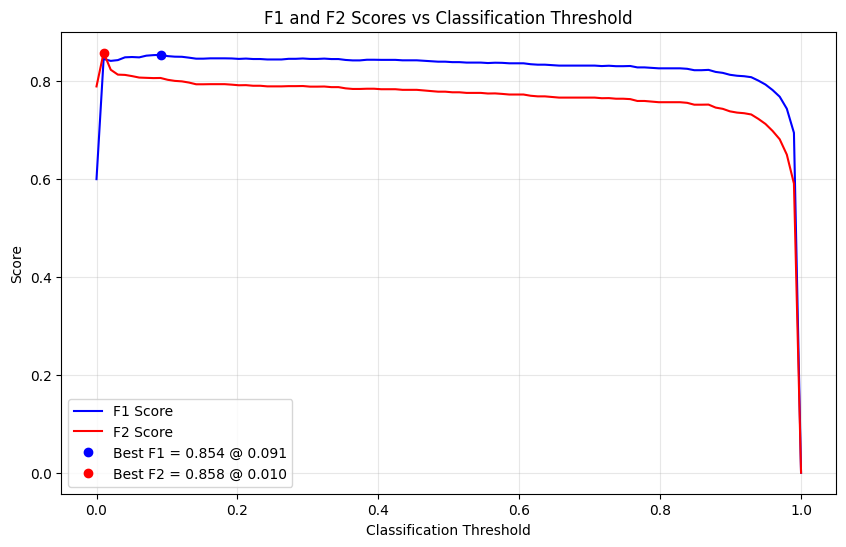

F1: Best score 0.854 at threshold 0.091
F2: Best score 0.858 at threshold 0.010


In [9]:
print("\n=== Evaluating Original Test Set (Non-excluded Data) ===")
opt_thresh_f1, opt_thresh_f2, best_f1, best_f2 = plot_threshold_f1f2_curve(
    model=model,
    test_loader=test_loader,
    device=device,
    task=args.task
)
print(f"F1: Best score {best_f1:.3f} at threshold {opt_thresh_f1:.3f}")
print(f"F2: Best score {best_f2:.3f} at threshold {opt_thresh_f2:.3f}")


=== Evaluating Excluded Test Set ===


/home/merileo/ssamba/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


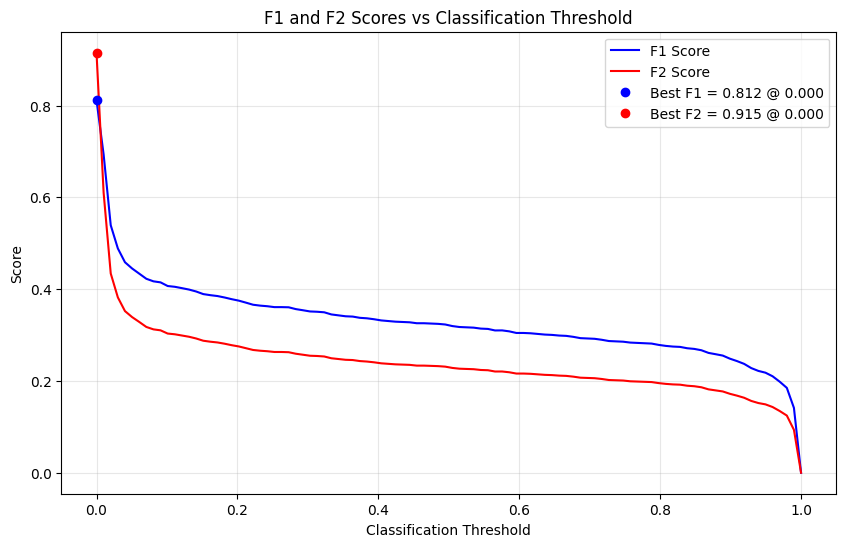

F1: Best score 0.812 at threshold 0.000
F2: Best score 0.915 at threshold 0.000


In [10]:
print("\n=== Evaluating Excluded Test Set ===")
opt_thresh_f1, opt_thresh_f2, best_f1, best_f2 = plot_threshold_f1f2_curve(
    model=model,
    test_loader=excluded_test_loader,
    device=device,
    task=args.task
)
print(f"F1: Best score {best_f1:.3f} at threshold {opt_thresh_f1:.3f}")
print(f"F2: Best score {best_f2:.3f} at threshold {opt_thresh_f2:.3f}")


=== Evaluating Full Test Set (Combined) ===


/home/merileo/ssamba/myenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


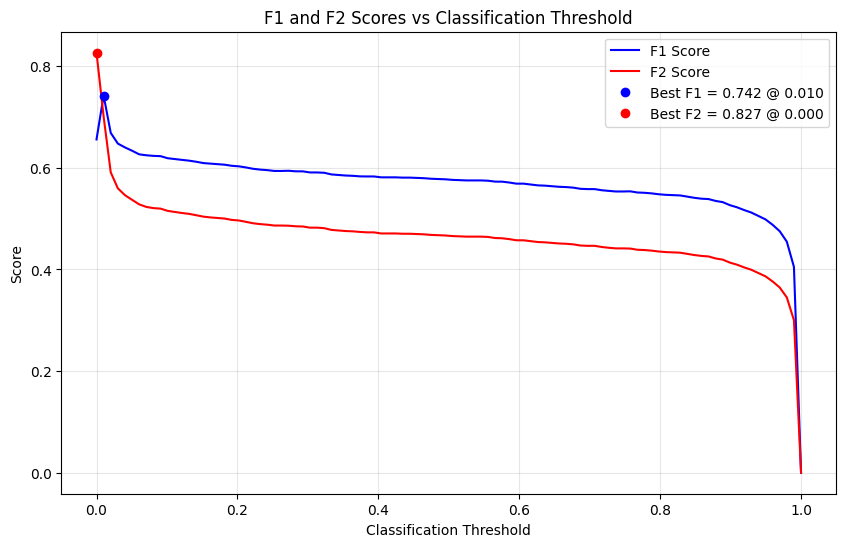

F1: Best score 0.742 at threshold 0.010
F2: Best score 0.827 at threshold 0.000


In [11]:
print("\n=== Evaluating Full Test Set (Combined) ===")
opt_thresh_f1, opt_thresh_f2, best_f1, best_f2 = plot_threshold_f1f2_curve(
    model=model,
    test_loader=full_test_loader,
    device=device,
    task=args.task
)
print(f"F1: Best score {best_f1:.3f} at threshold {opt_thresh_f1:.3f}")
print(f"F2: Best score {best_f2:.3f} at threshold {opt_thresh_f2:.3f}")

In [12]:
metrics, y_true, y_pred, sources = evaluate_model(model, test_loader, threshold=best_f2)
print("Original test set metrics:", metrics)

excluded_metrics, excluded_y_true, excluded_y_pred, excluded_sources = evaluate_model(
    model, excluded_test_loader, threshold=0.01
)
print("Excluded test set metrics:", excluded_metrics)

full_metrics, full_y_true, full_y_pred, full_sources = evaluate_model(
    model, full_test_loader, threshold=0.04
)
print("Full test set metrics:", full_metrics)

Original test set metrics: {'accuracy': 0.8709090909090909, 'precision': 0.975, 'recall': 0.7171145685997171, 'f1': 0.8264058679706601, 'f2': 0.7571684587813619, 'normal_acc': 0.9862142099681867, 'anomaly_acc': 0.7171145685997171}
Excluded test set metrics: {'accuracy': 0.6619623655913979, 'precision': 0.898989898989899, 'recall': 0.5691096901131333, 'f1': 0.696987951807229, 'f2': 0.6141840959762183, 'normal_acc': 0.8621420996818664, 'anomaly_acc': 0.5691096901131333}
Full test set metrics: {'accuracy': 0.7276676622318762, 'precision': 0.8977955911823647, 'recall': 0.4986087924318308, 'f1': 0.6411449016100179, 'f2': 0.5472758367945272, 'normal_acc': 0.9459172852598091, 'anomaly_acc': 0.4986087924318308}


In [13]:
# First analysis: Just the excluded data
excluded_metrics = analyze_excluded_data(full_test_dataset, full_y_pred, EXCLUDED_LABELS)

IndexError: index 3683 is out of bounds for axis 0 with size 3683

In [27]:
excluded_metrics

{'overall_metrics': {'auroc': None,
  'precision': 1.0,
  'recall': 0.5,
  'f1': 0.6666666666666666,
  'f2': 0.5555555555555556},
 'anomaly_type_metrics': {'Dropout': {'count': 1322,
   'metrics': {'auroc': None,
    'precision': 1.0,
    'recall': 0.5574886535552194,
    'f1': 0.7158814958717824,
    'f2': 0.6116182572614108}},
  'Tonal': {'count': 1906,
   'metrics': {'auroc': None,
    'precision': 1.0,
    'recall': 0.41867785939139557,
    'f1': 0.5902366863905325,
    'f2': 0.4737592020897649}}},
 'excluded_samples': [{'index': 947,
   'labels': ['Dropout'],
   'prediction': 1,
   'source': 'ICLISTENHF1266'},
  {'index': 952,
   'labels': ['Tonal'],
   'prediction': 0,
   'source': 'JASCOAMARHYDROPHONED001022'},
  {'index': 954,
   'labels': ['Tonal', 'Dropout'],
   'prediction': 0,
   'source': 'ICLISTENHF6095'},
  {'index': 955,
   'labels': ['Tonal'],
   'prediction': 0,
   'source': 'JASCOAMARHYDROPHONEE000186'},
  {'index': 960,
   'labels': ['Dropout', 'Tonal'],
   'predict

In [ ]:
excluded_metrics

,anomaly_type,total_samples,solo_samples,co_occurring_samples,overall_detection_rate,solo_detection_rate,co_detection_rate,top_co_occurring,percent_solo
0,Dropout,1322,336,986,0.557489,0.955357,0.421907,"{'Tonal': 982, 'Unknown Feature': 181, 'Rain':...",0.254160
1,Tonal,1906,872,1034,0.418678,0.383028,0.448743,"{'Dropout': 982, 'Unknown Feature': 179, 'Rain...",0.457503


In [ ]:
# Second analysis: Full test set
full_metrics = analyze_full_test_set(test_dataset, y_pred, EXCLUDED_LABELS)

In [10]:
full_metrics

,anomaly_type,was_excluded,total_samples,solo_samples,co_occurring_samples,overall_detection_rate,solo_detection_rate,co_detection_rate,top_co_occurring,percent_solo
0,Anomaly,False,13,7,6,1.000000,1.000000,1.0,"{'Dropout': 6, 'Data Gap': 6, 'Tonal': 6}",0.538462
1,Data Gap,False,54,48,6,0.981481,0.979167,1.0,"{'Dropout': 6, 'Anomaly': 6, 'Tonal': 6}",0.888889
2,Dropout,True,1322,336,986,0.991679,0.967262,1.0,"{'Tonal': 982, 'Unknown Feature': 181, 'Rain':...",0.254160
3,Engine Noise,False,430,377,53,0.990698,0.989390,1.0,"{'Rain': 29, 'Tonal': 24, 'Dropout': 21}",0.876744
4,Rain,False,134,26,108,0.992537,0.961538,1.0,"{'Dropout': 79, 'Tonal': 78, 'Unknown Feature'...",0.194030
5,Sensitivity,False,2,2,0,0.500000,0.500000,No co-occurring samples,{},1.000000
6,Tonal,False,1063,78,985,1.000000,1.000000,1.0,"{'Dropout': 982, 'Unknown Feature': 177, 'Rain...",0.073377
7,Unknown Feature,False,186,5,181,0.989247,0.600000,1.0,"{'Dropout': 181, 'Tonal': 177, 'Rain': 35}",0.026882


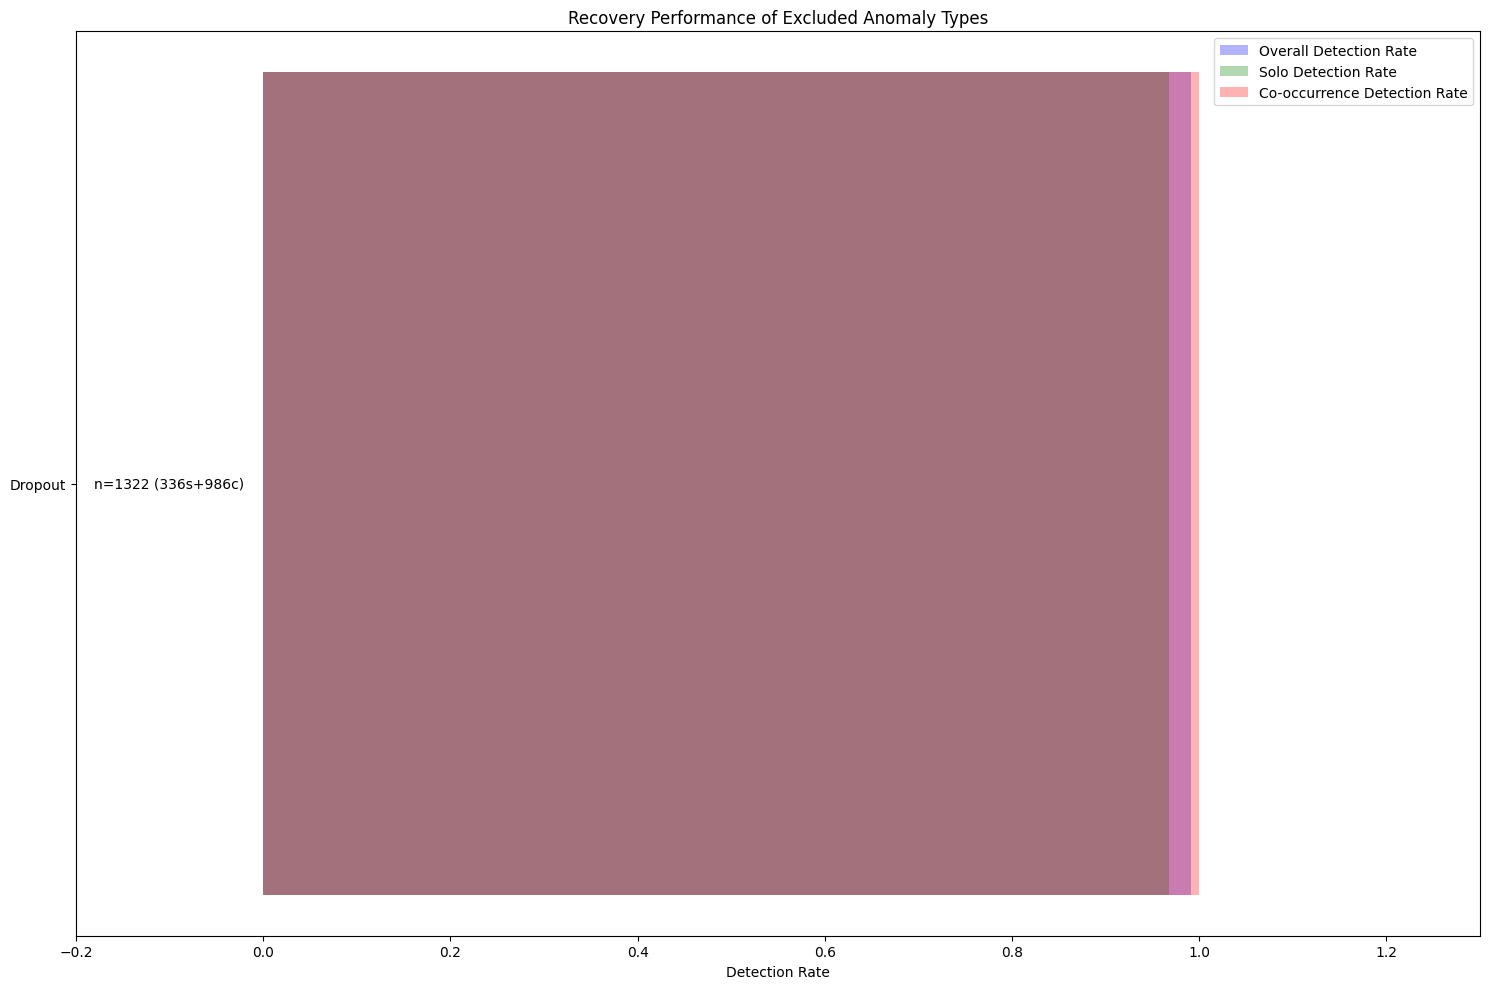

In [33]:
plot_excluded_analysis(excluded_metrics)

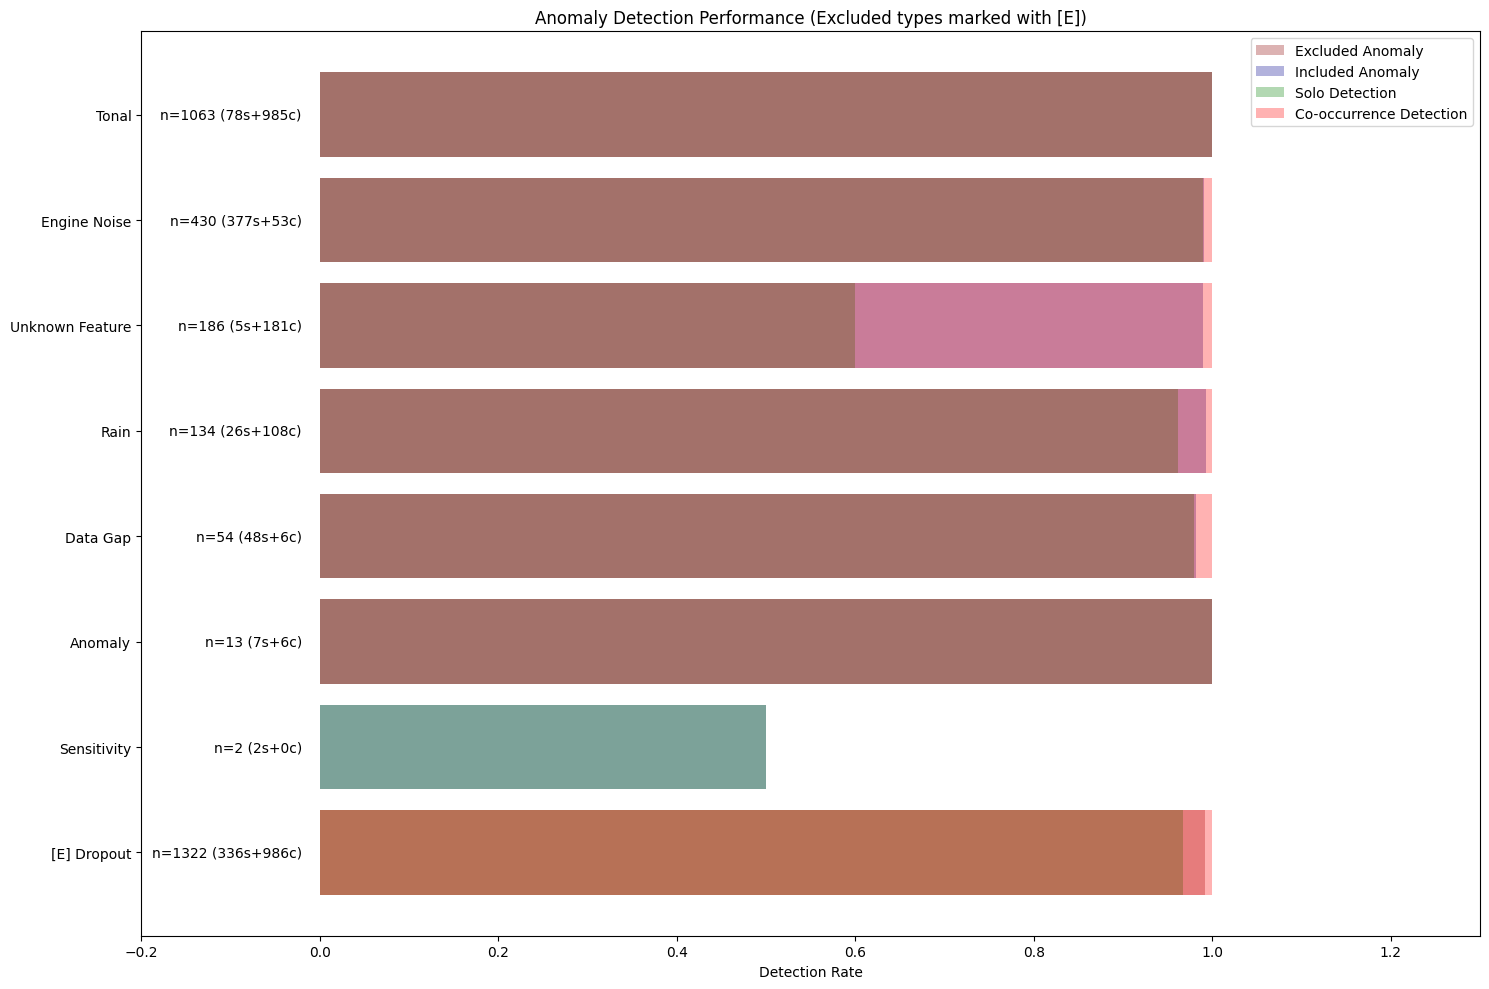

In [39]:
plot_full_test_analysis(full_metrics)

In [23]:
compare_excluded_vs_included_performance(test_dataset, y_pred, EXCLUDED_LABELS)

,anomaly_type,group,total_samples,solo_samples,co_occurring_samples,overall_detection_rate,solo_detection_rate,co_detection_rate,top_co_occurring,percent_solo
0,Dropout,Excluded,1322,336,986,0.991679,0.967262,1.0,"{'Tonal': 982, 'Unknown Feature': 181, 'Rain':...",0.254160
1,Tonal,Included,1063,78,985,1.000000,1.000000,1.0,"{'Dropout': 982, 'Unknown Feature': 177, 'Rain...",0.073377
4,Engine Noise,Included,430,377,53,0.990698,0.989390,1.0,"{'Rain': 29, 'Tonal': 24, 'Dropout': 21}",0.876744
7,Unknown Feature,Included,186,5,181,0.989247,0.600000,1.0,"{'Dropout': 181, 'Tonal': 177, 'Rain': 35}",0.026882
5,Rain,Included,134,26,108,0.992537,0.961538,1.0,"{'Dropout': 79, 'Tonal': 78, 'Unknown Feature'...",0.194030
6,Data Gap,Included,54,48,6,0.981481,0.979167,1.0,"{'Dropout': 6, 'Anomaly': 6, 'Tonal': 6}",0.888889
3,Anomaly,Included,13,7,6,1.000000,1.000000,1.0,"{'Dropout': 6, 'Tonal': 6, 'Data Gap': 6}",0.538462
2,Sensitivity,Included,2,2,0,0.500000,0.500000,No co-occurring samples,{},1.000000


In [18]:
# Get hydrophone-specific metrics
hydrophone_df = evaluate_by_hydrophone(y_true, y_pred, sources)
display(hydrophone_df)



,hydrophone,samples,anomaly_rate,precision,recall,f1,f2,num_normal,num_anomaly,pred_normal,pred_anomaly
0,ICLISTENHF1252,17,1.000000,1.000000,1.000000,1.000000,1.000000,0,17,0,17
1,ICLISTENHF1253,302,0.000000,0.000000,0.000000,0.000000,0.000000,302,0,296,6
2,ICLISTENHF1266,530,0.592453,0.967949,0.961783,0.964856,0.963010,216,314,218,312
3,ICLISTENHF1354,451,0.891353,0.956731,0.990050,0.973105,0.983202,49,402,35,416
4,ICLISTENHF1951,92,0.358696,0.914286,0.969697,0.941176,0.958084,59,33,57,35
5,ICLISTENHF6020,91,0.000000,0.000000,0.000000,0.000000,0.000000,91,0,90,1
6,ICLISTENHF6093,63,0.000000,1.000000,0.000000,0.000000,0.000000,63,0,63,0
7,ICLISTENHF6094,70,0.000000,0.000000,0.000000,0.000000,0.000000,70,0,69,1
8,ICLISTENHF6095,993,1.000000,1.000000,1.000000,1.000000,1.000000,0,993,0,993
9,ICLISTENHF6324,153,0.392157,0.982759,0.950000,0.966102,0.956376,93,60,95,58


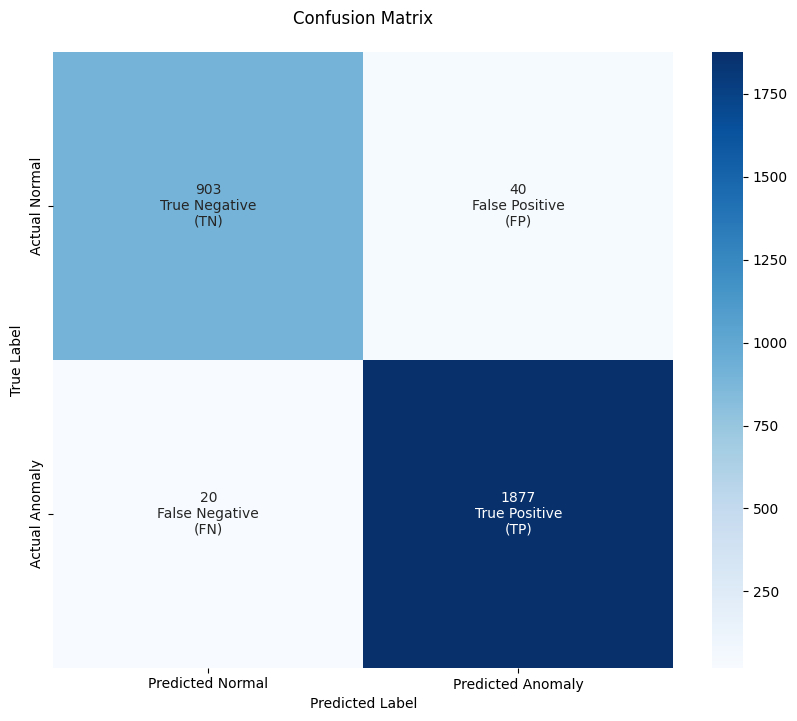

In [13]:
# Plot confusion matrix
plot_confusion_matrix(y_true, y_pred)


Category sizes:
True Positives: 1877
True Negatives: 903
False Positives: 40
False Negatives: 20


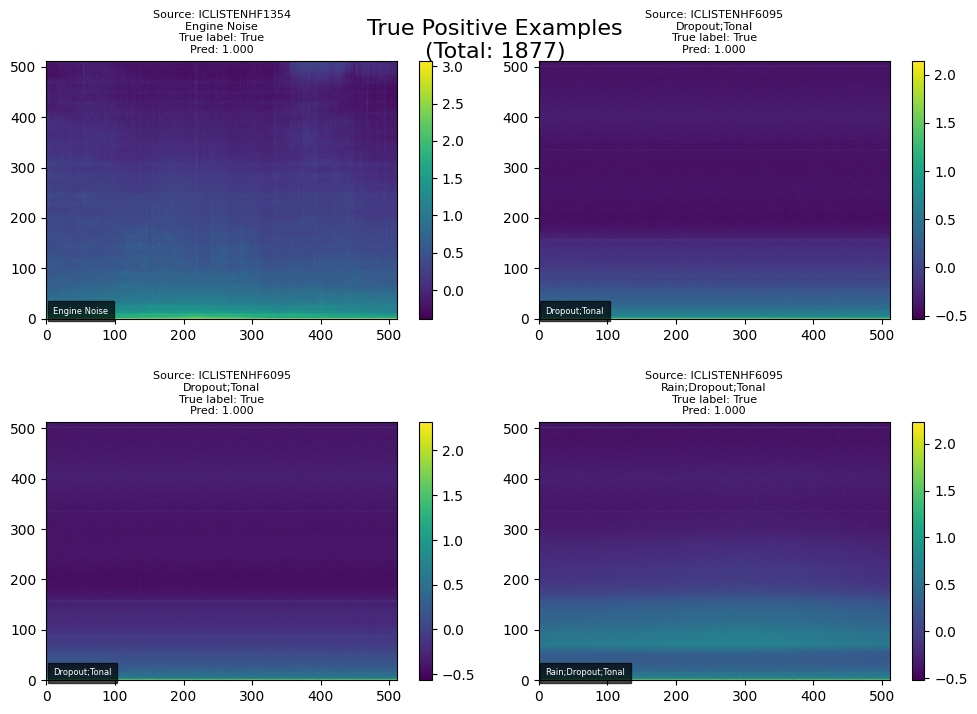

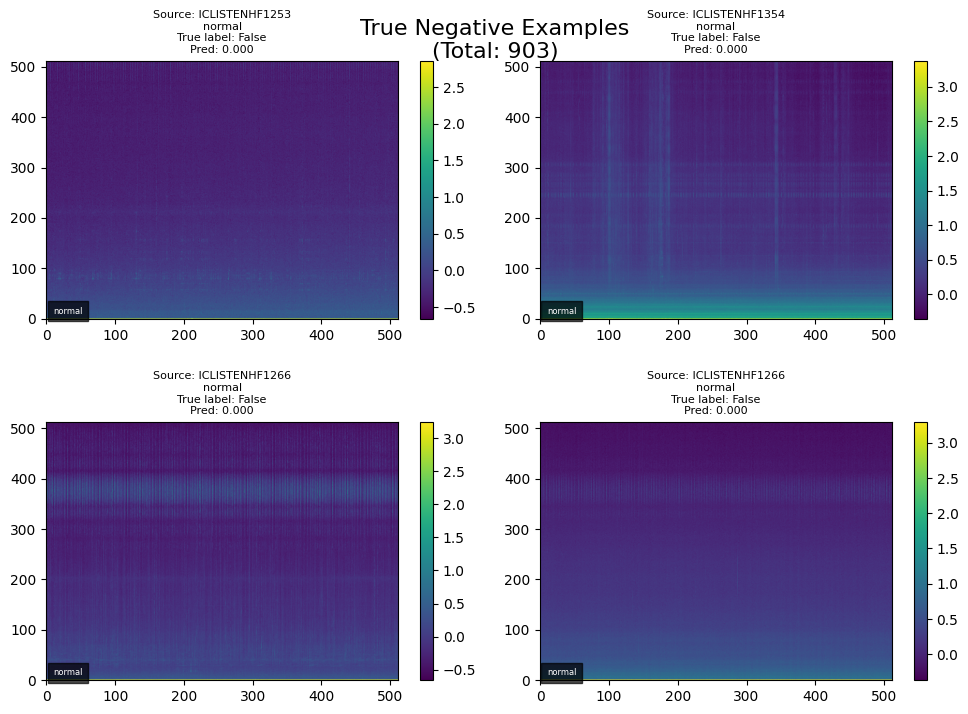

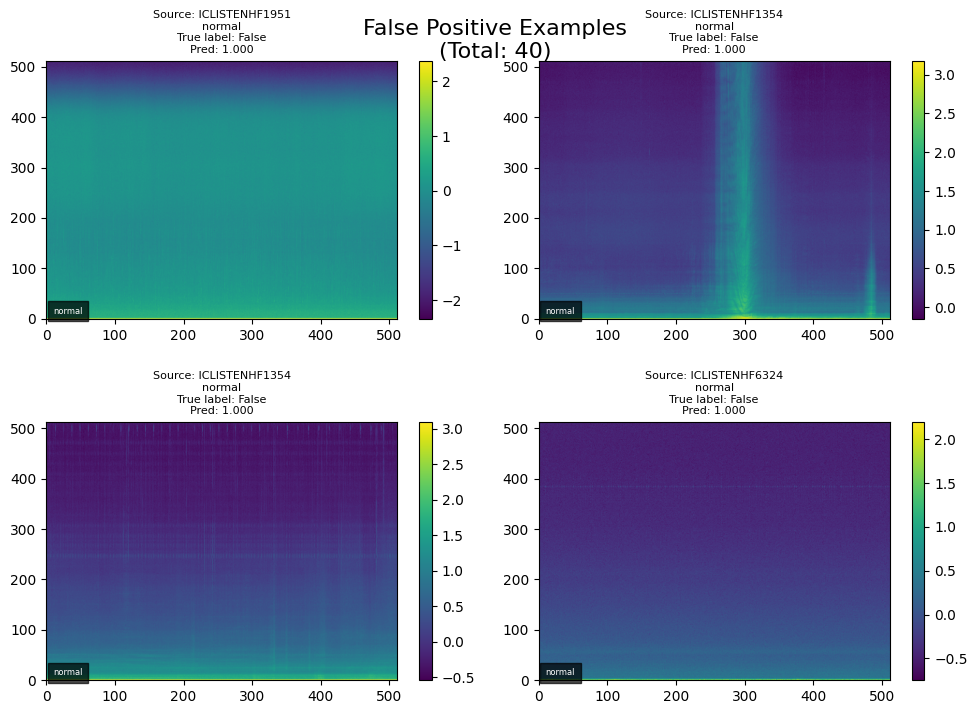

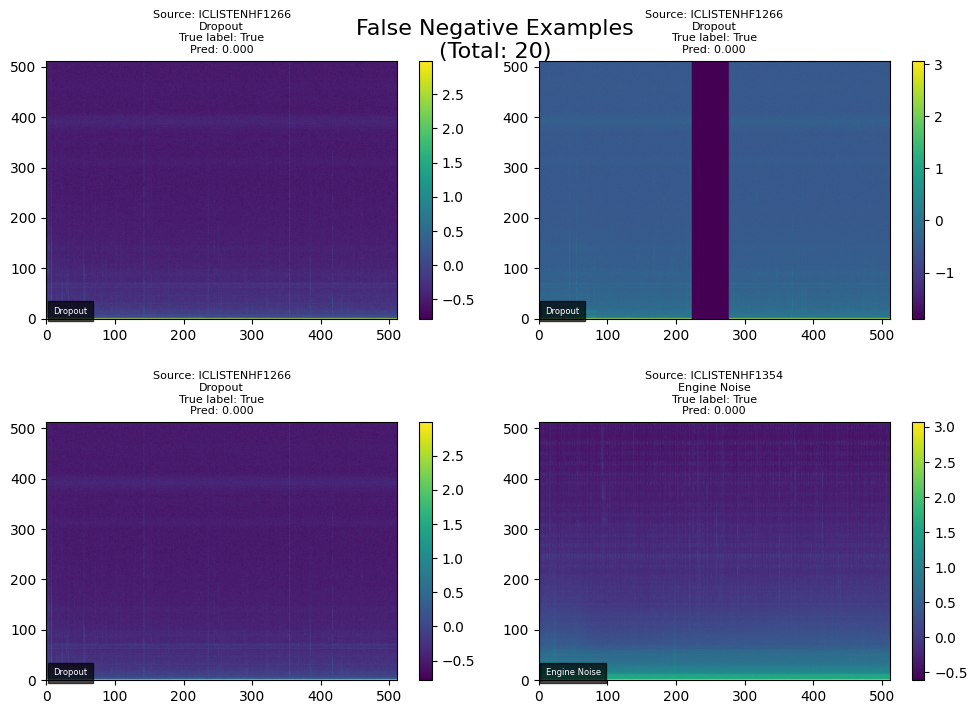

In [26]:
# Show example spectrograms
plot_example_spectrograms(test_dataset, y_pred, num_examples=4, samples_per_row=2)

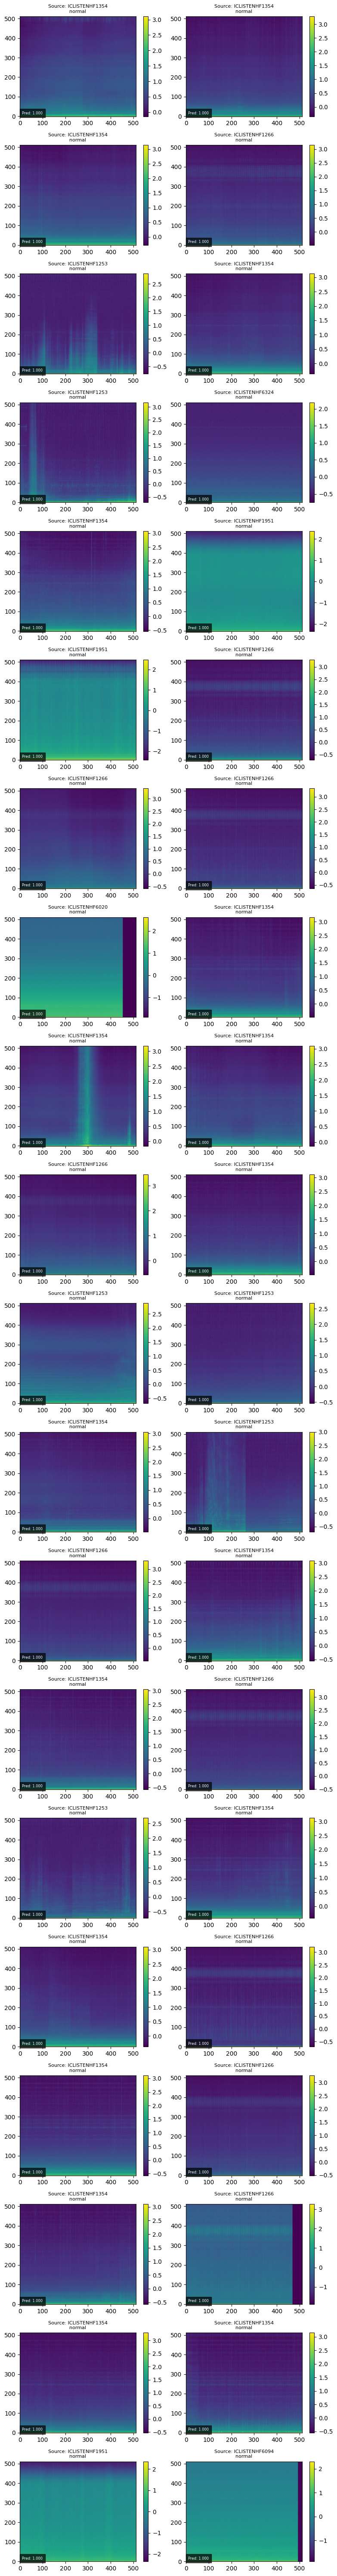

In [27]:
# To see all false positives
plot_all_false_positives(test_dataset, y_pred, samples_per_row=2)

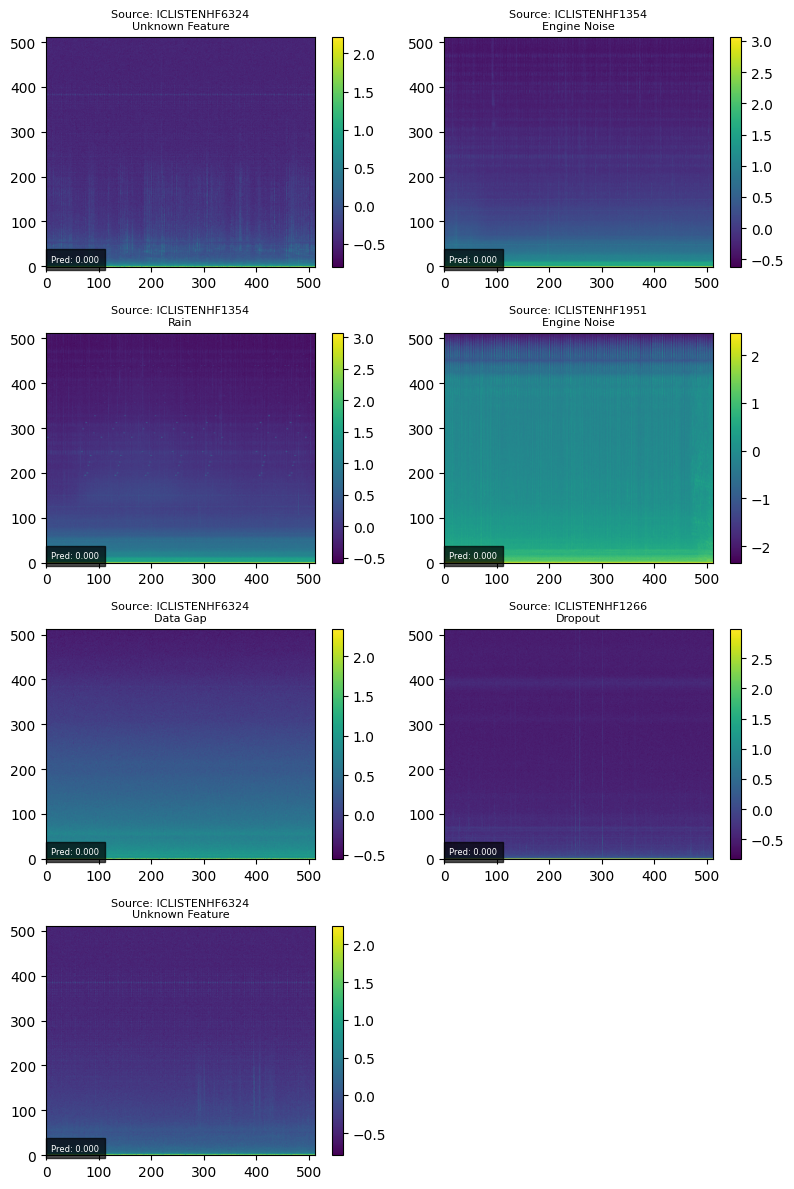

In [12]:
# To see all false negatives
plot_all_false_negatives(test_dataset, y_pred, samples_per_row=2)

In [8]:
anomaly_metrics, co_occurrence_metrics = evaluate_by_anomaly_type(full_test_dataset, full_y_pred)

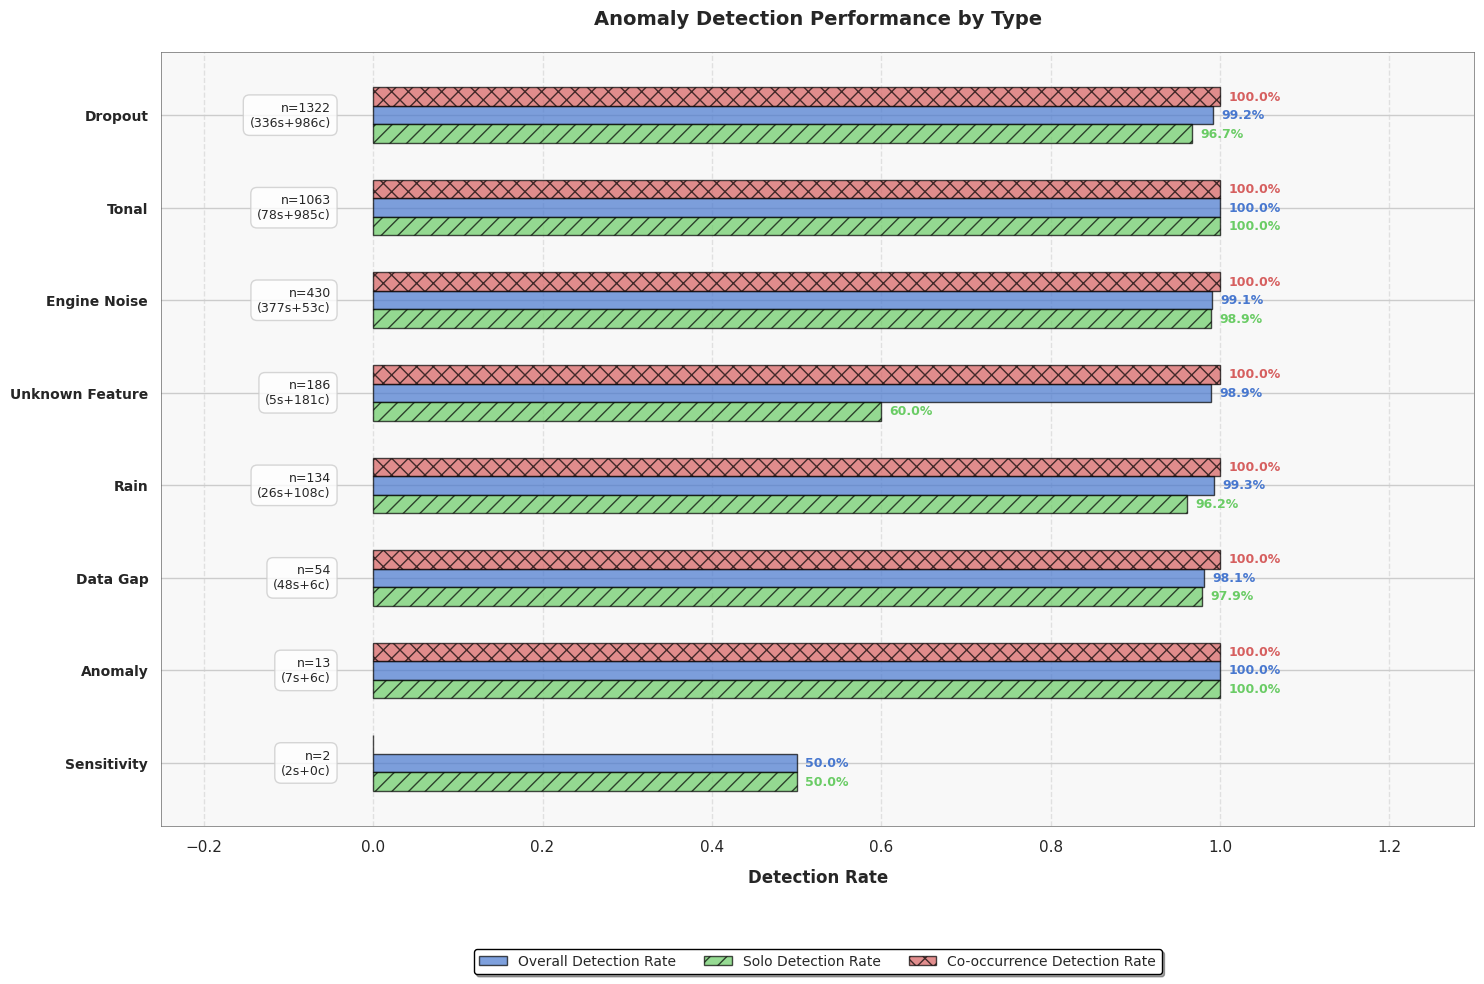

In [9]:
# Plot anomaly type metrics
plot_anomaly_type_metrics(anomaly_metrics)

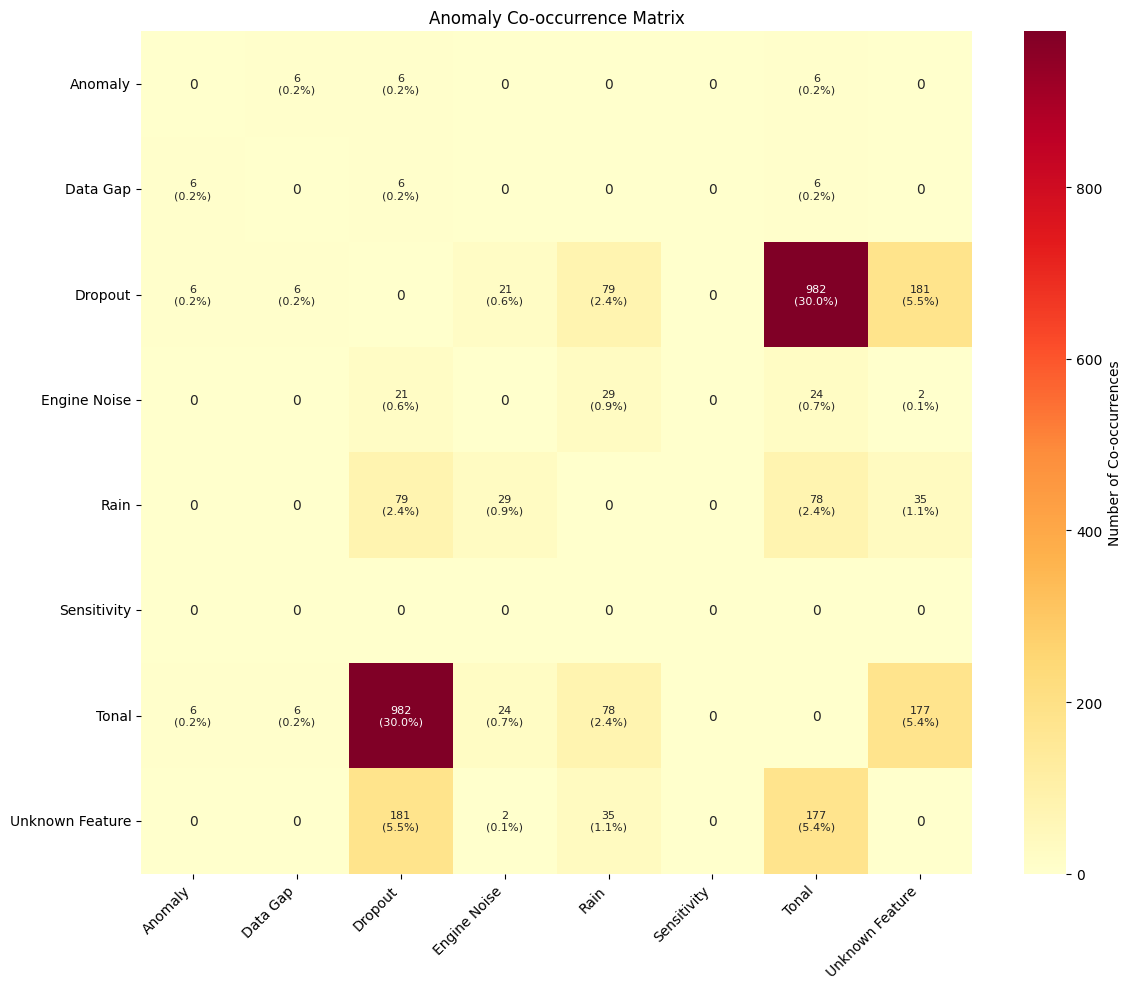

In [12]:
# Plot co-occurrence matrix
plot_co_occurrence_matrix(test_dataset)

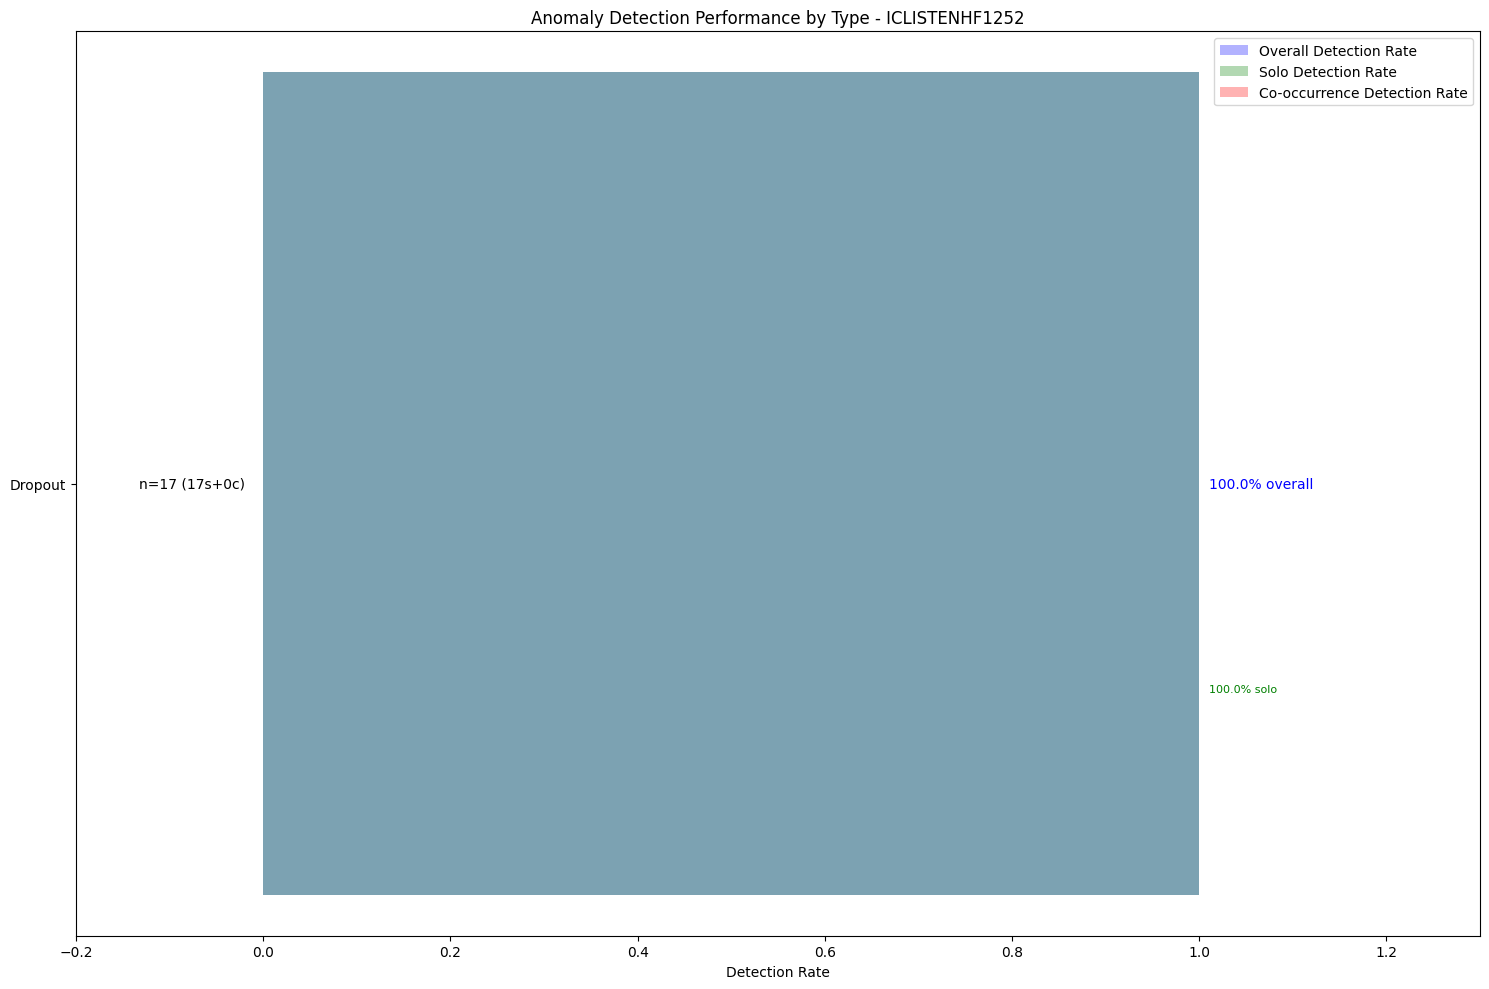

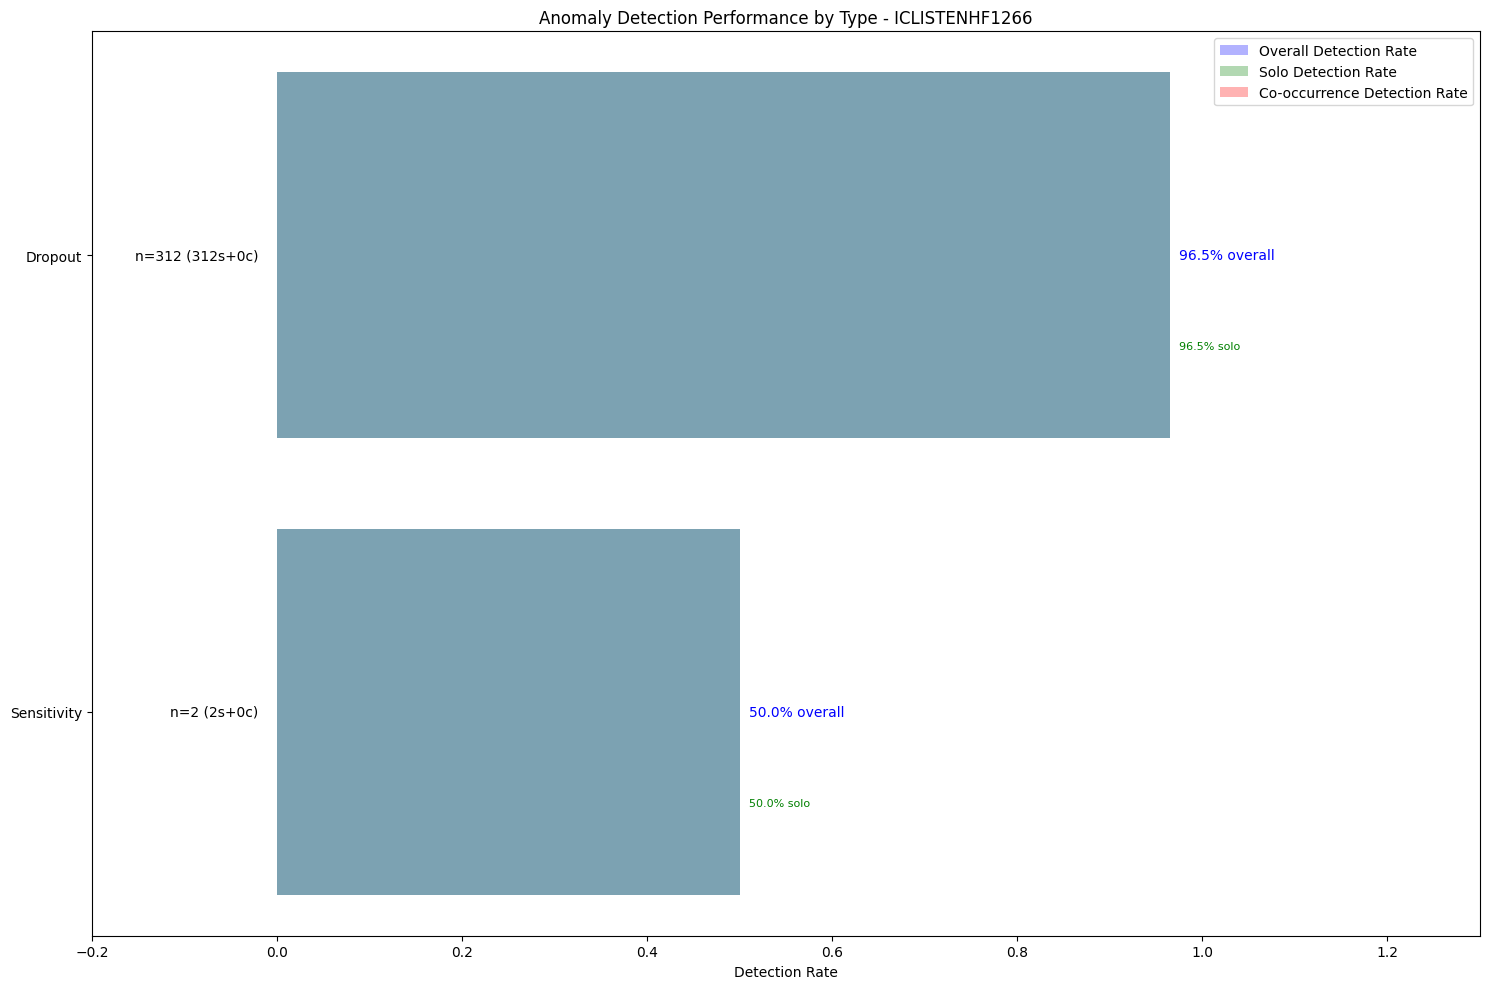

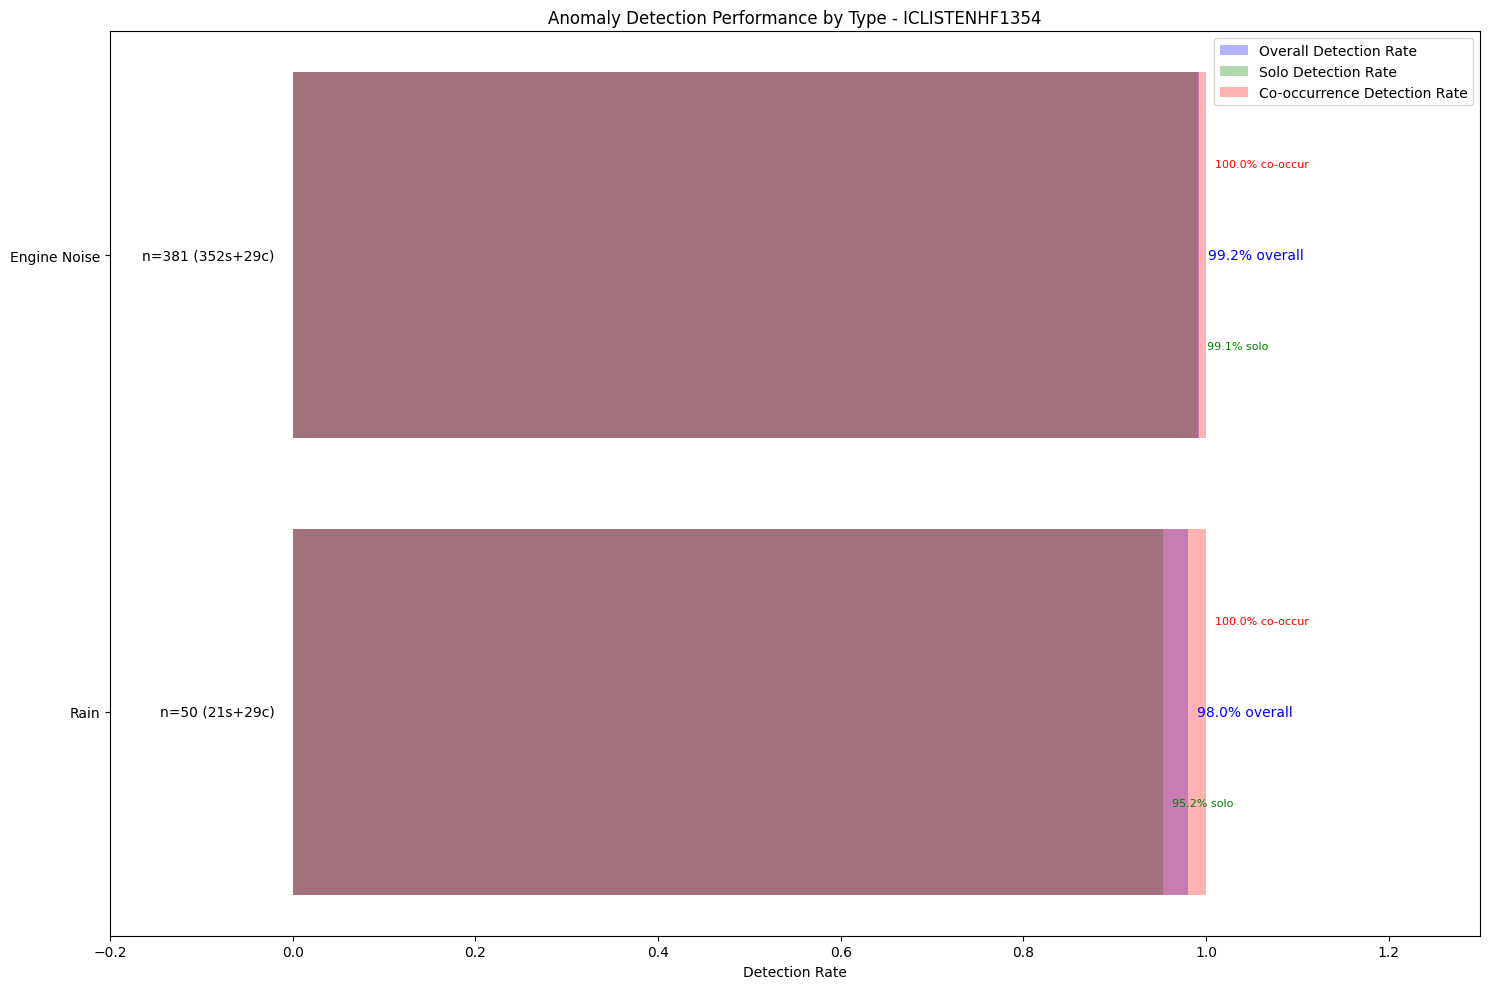

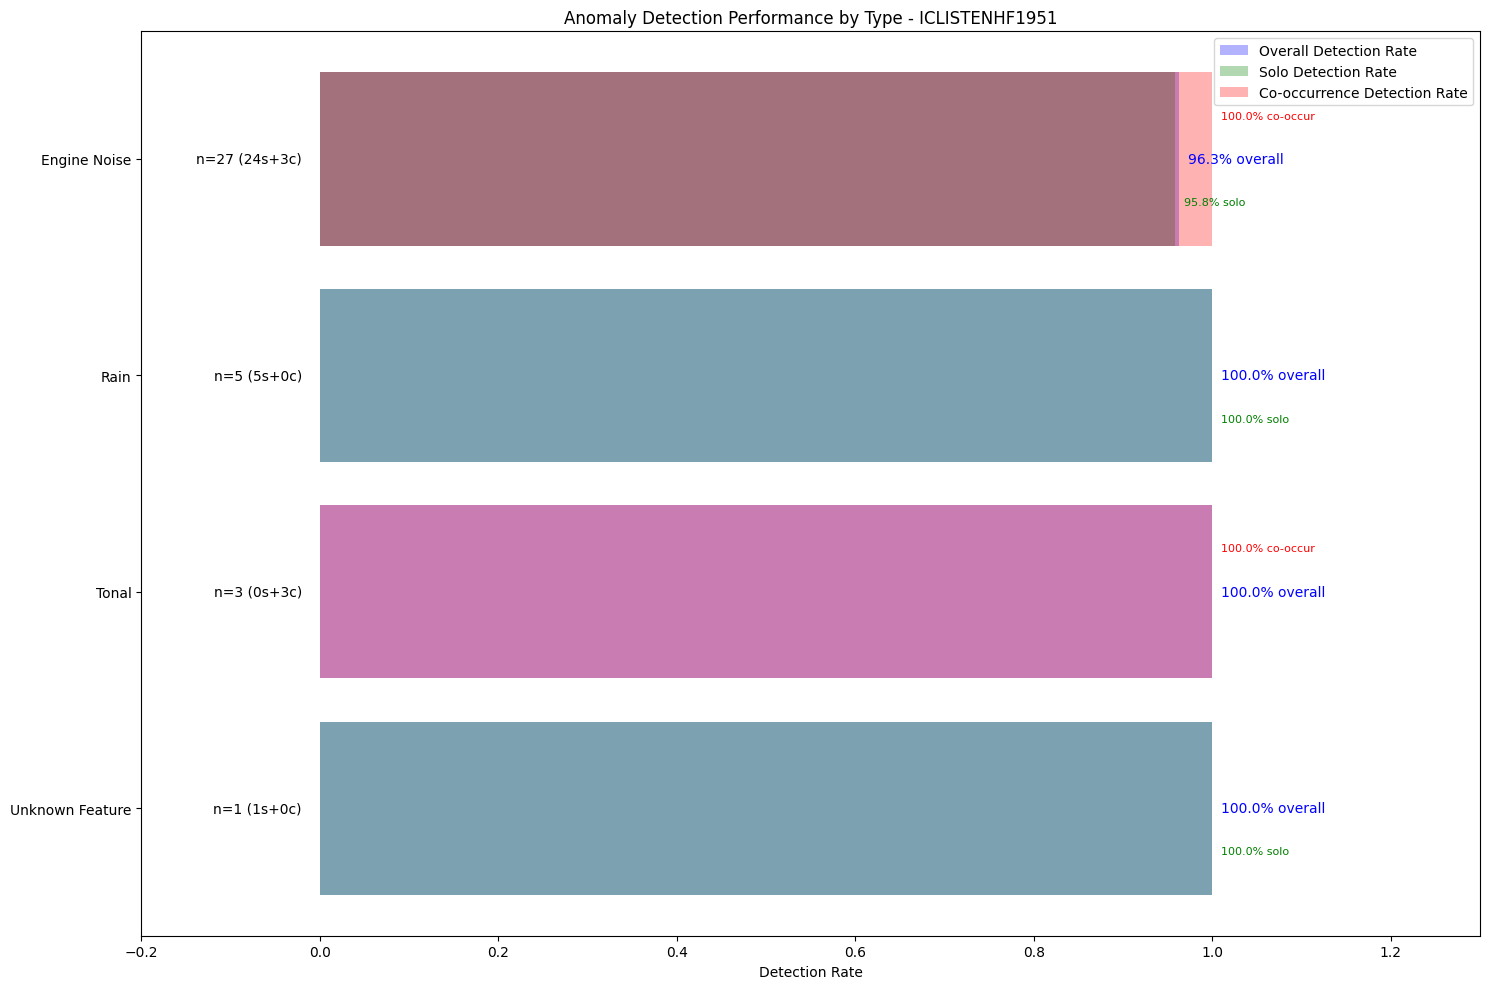

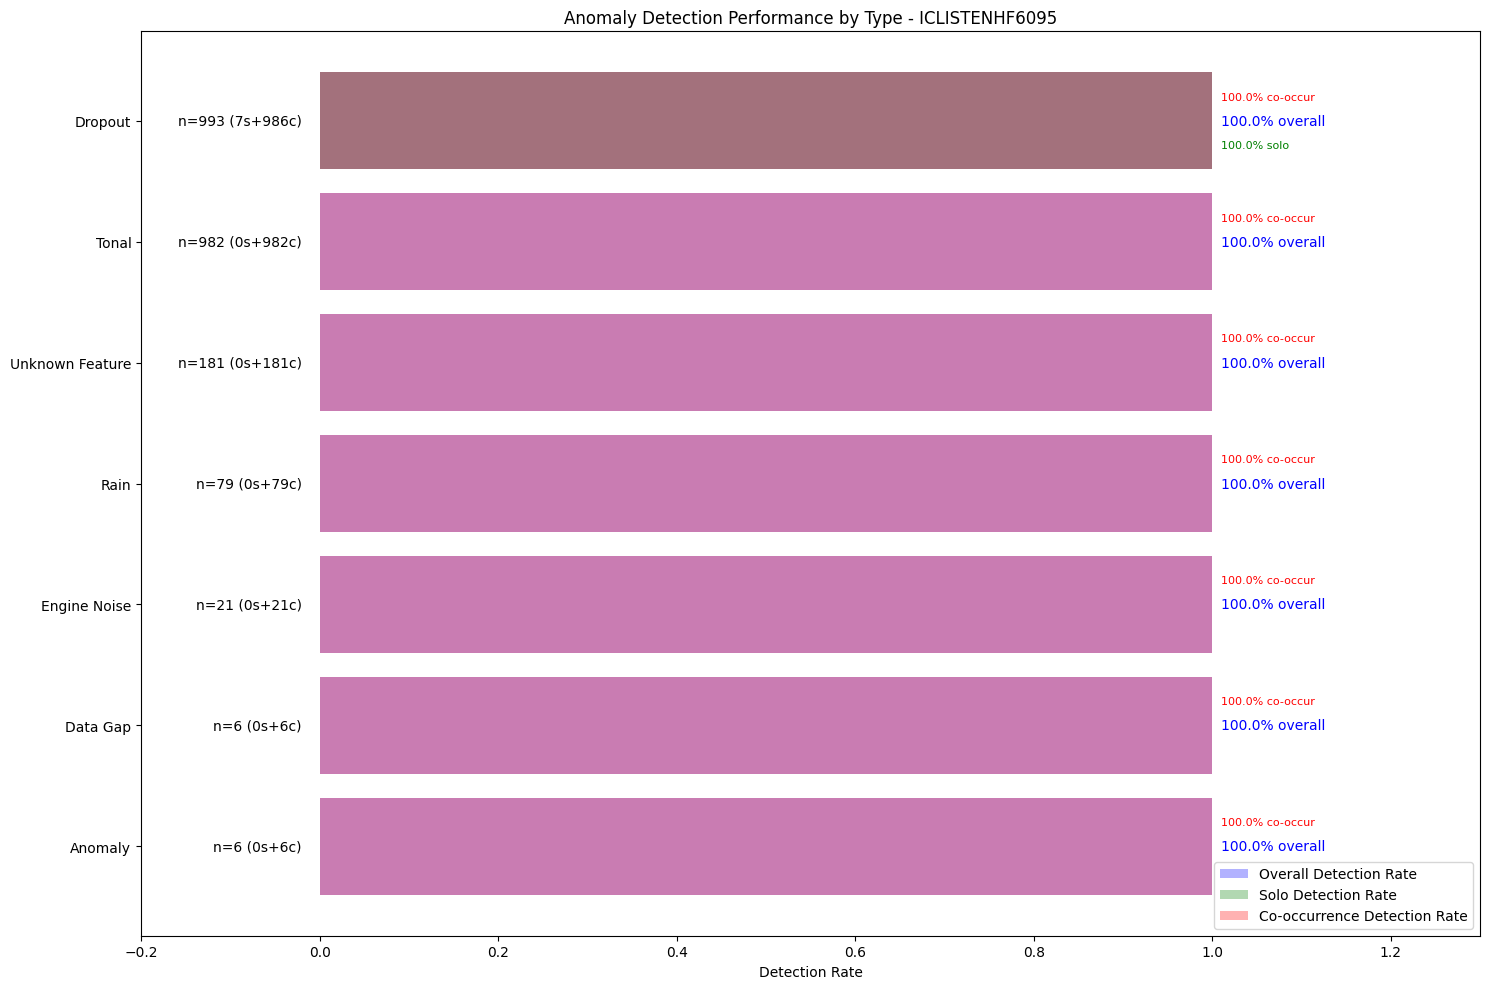

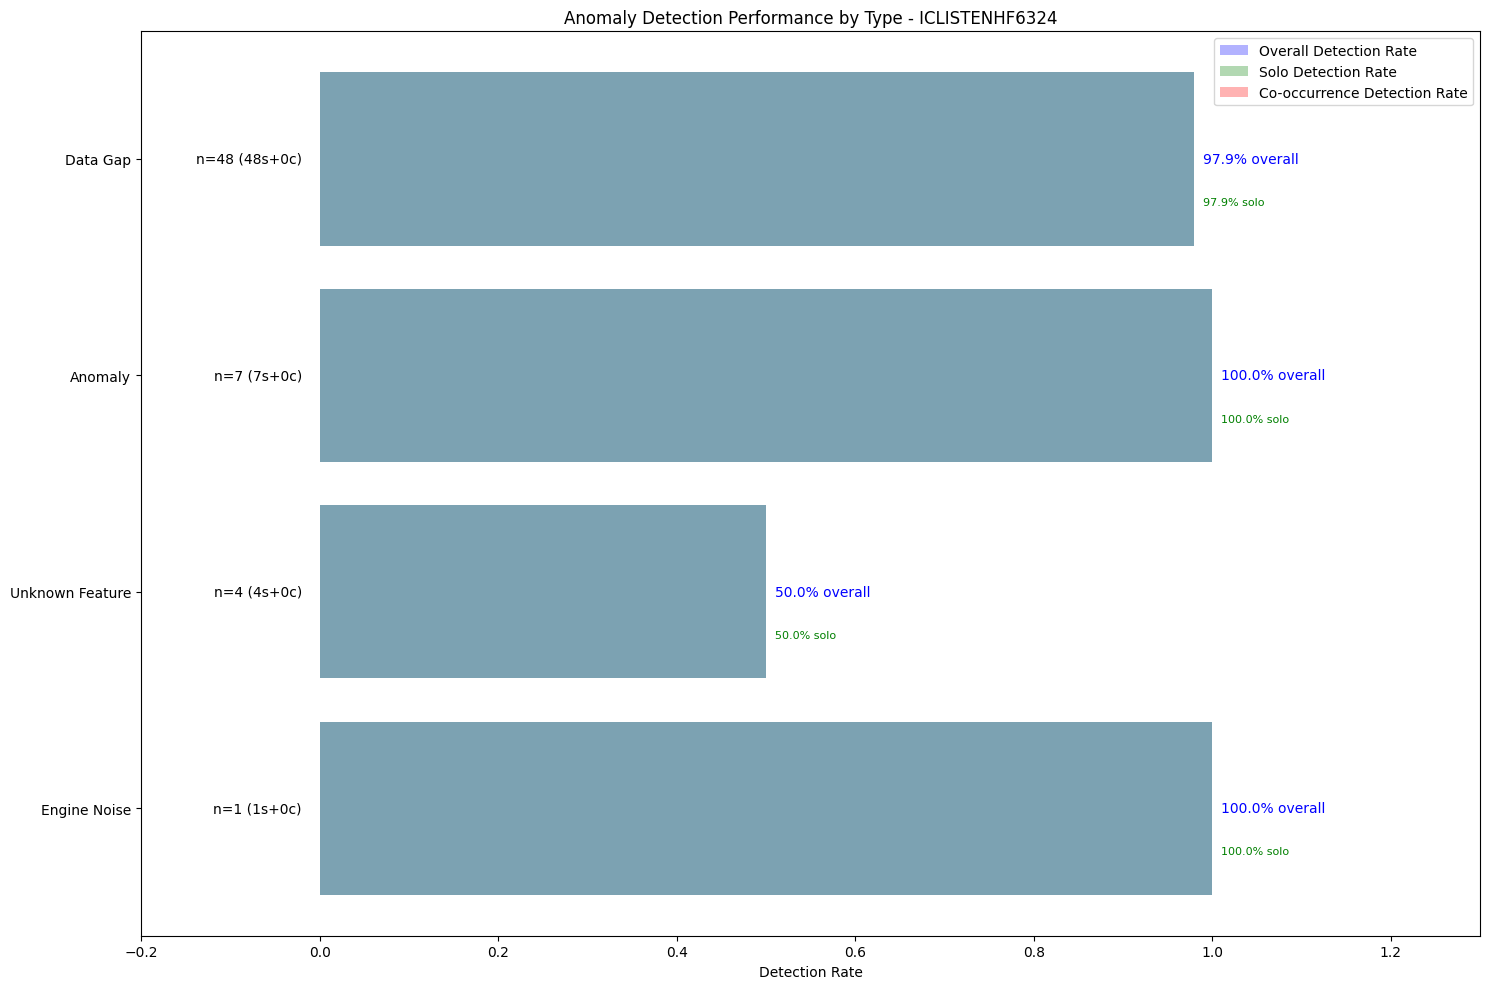

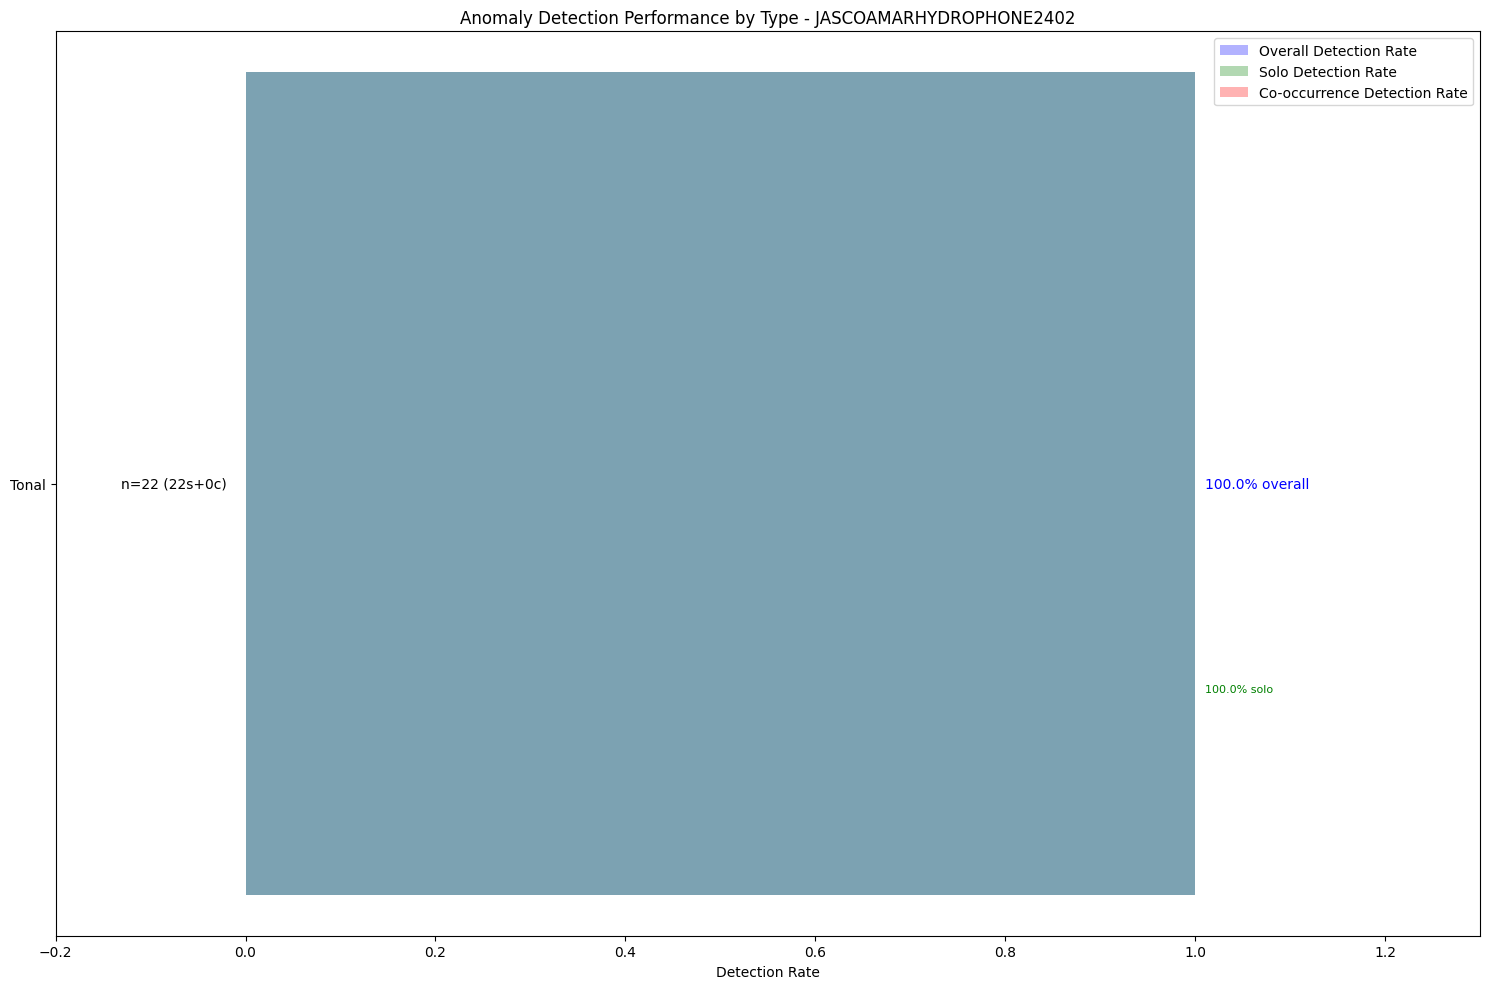

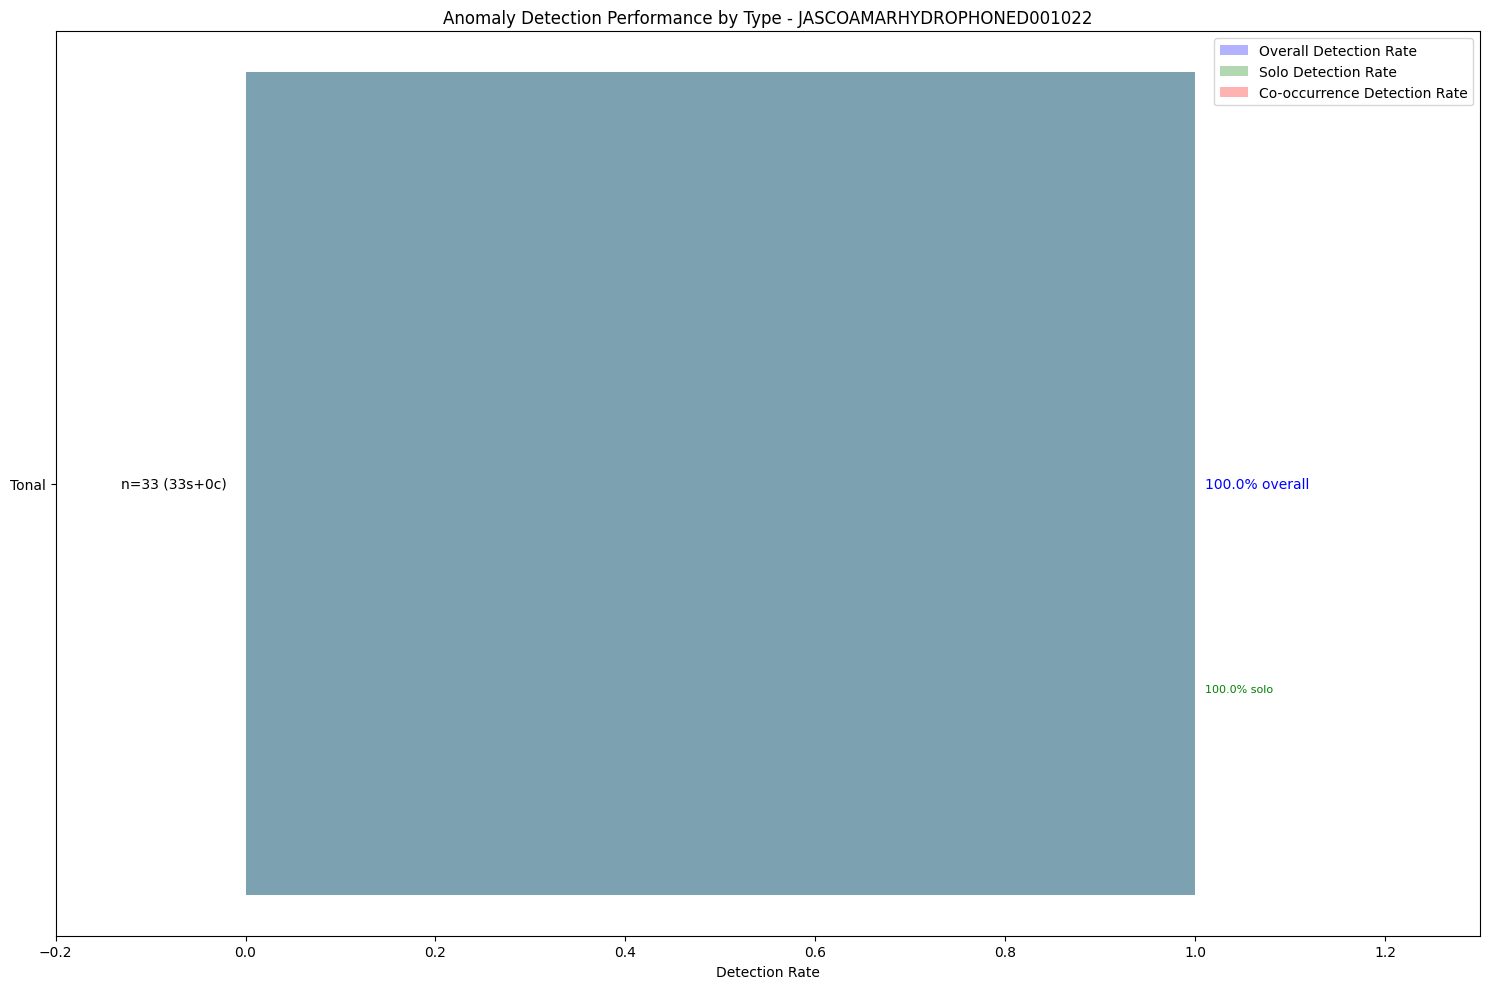

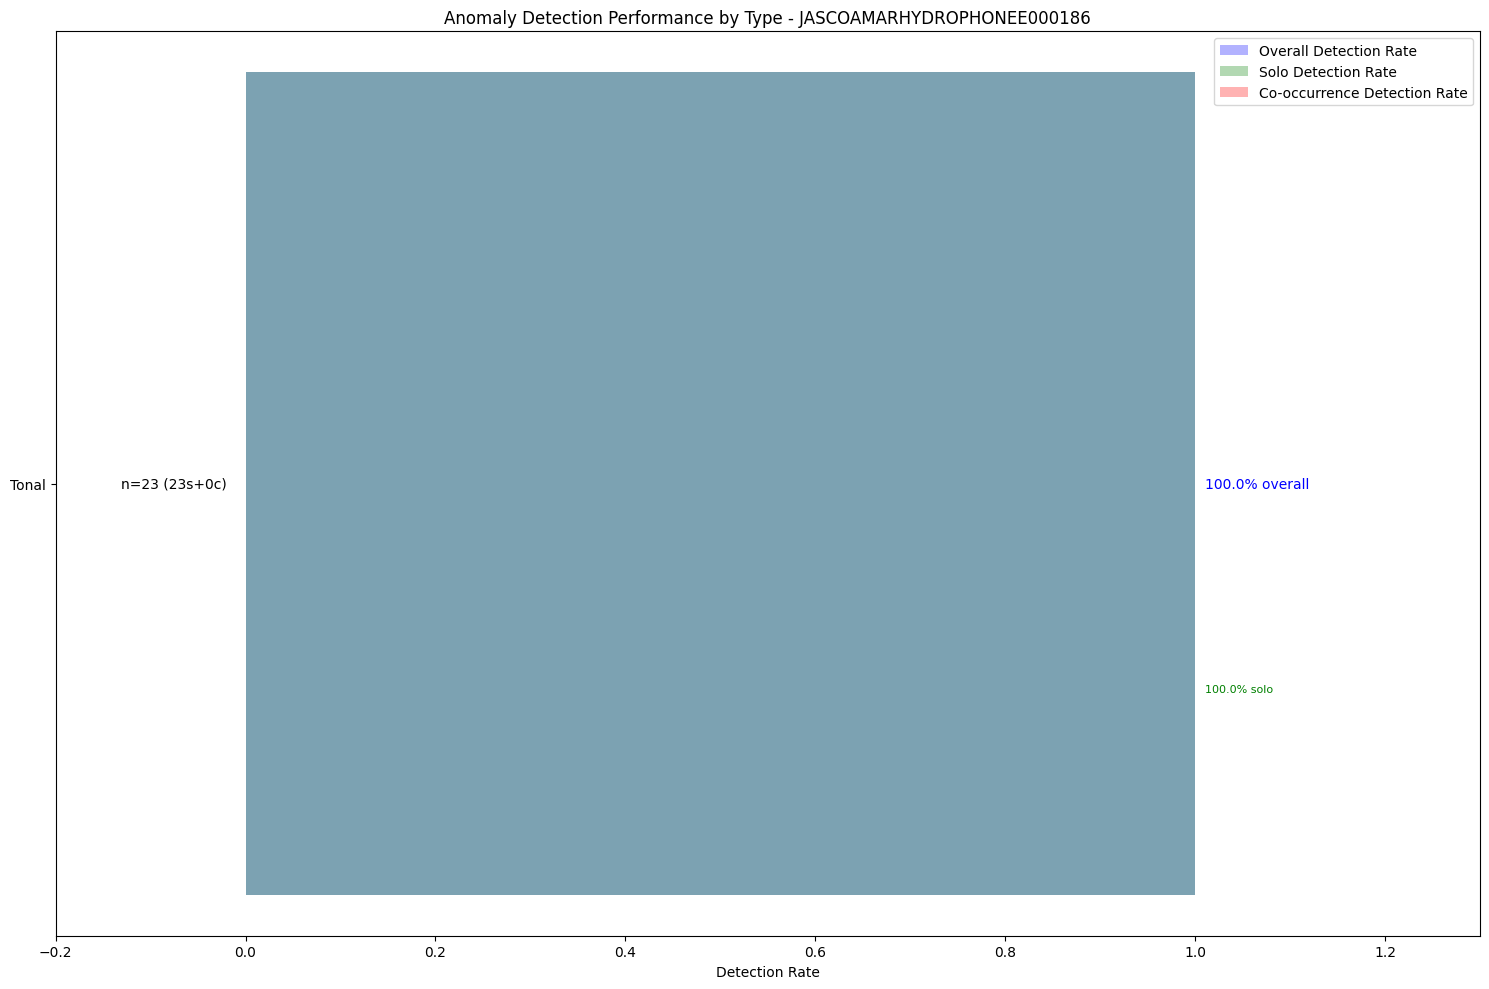

In [13]:
hydrophone_metrics = plot_anomaly_type_by_hydrophone(test_dataset, y_pred, threshold=0.5)